# 01 — Dataset EDA

Exploratory look at the committed synthetic CWRU-like and IMS-like datasets (`data/raw/{cwru,ims}/synthetic/`) — see `data/README.md` for how they were generated and why synthetic data is used by default.


In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from src.data.cwru_loader import load_cwru_dataset
from src.data.ims_loader import load_ims_dataset


## CWRU-like synthetic set: one window per (health_state, load_hp)

In [2]:
cwru_records = load_cwru_dataset('../data/raw/cwru/synthetic', source='synthetic')
cwru_df = pd.DataFrame([
    {'health_state': r.health_state, 'load_hp': r.load_hp, 'rpm': r.rpm,
     'shaft_freq_hz': r.shaft_freq_hz, 'n_samples': r.signal.shape[1]}
    for r in cwru_records
])
cwru_df.groupby('health_state').size()


health_state
ball          4
compound      4
healthy       4
inner_race    4
outer_race    4
dtype: int64

In [3]:
fig, axes = plt.subplots(len(cwru_records[:5]), 1, figsize=(10, 8), sharex=True)
for ax, r in zip(axes, cwru_records[:5]):
    ax.plot(r.signal[0][:2000])
    ax.set_ylabel(r.health_state)
axes[-1].set_xlabel('sample index (x-axis accelerometer)')
fig.suptitle('First 2000 samples per health state (load 0 HP)')
fig.tight_layout()


## IMS-like synthetic run-to-failure trajectories

,bearing_id,snapshot_index,rul_cycles,health_indicator
0,1,0,19,0.000000
1,1,1,18,0.001980
2,1,2,17,0.004562
3,1,3,16,0.007928
4,1,4,15,0.012317


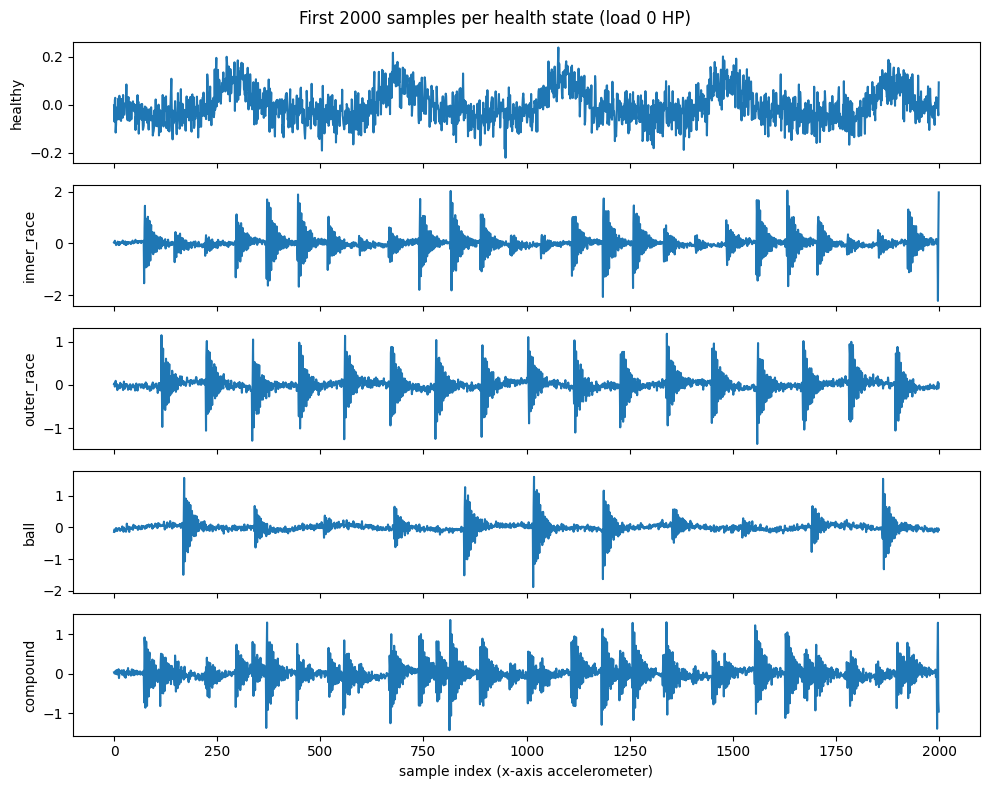

In [4]:
ims_records = load_ims_dataset('../data/raw/ims/synthetic', source='synthetic')
ims_df = pd.DataFrame([
    {'bearing_id': r.bearing_id, 'snapshot_index': r.snapshot_index,
     'rul_cycles': r.rul_cycles, 'health_indicator': r.health_indicator}
    for r in ims_records
]).sort_values(['bearing_id', 'snapshot_index'])
ims_df.head()


Text(0.5, 1.0, 'IMS-like synthetic run-to-failure trajectories')

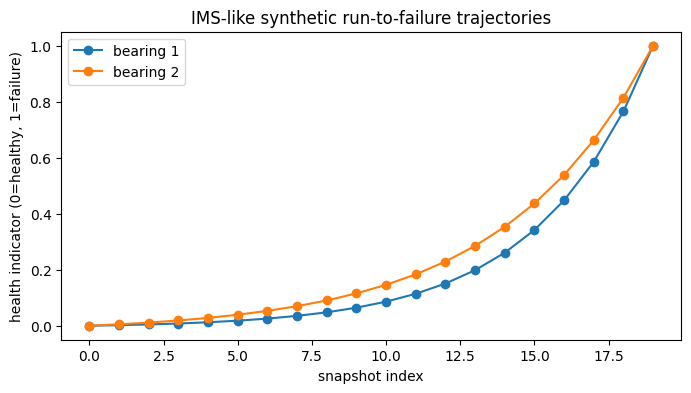

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for bearing_id, g in ims_df.groupby('bearing_id'):
    ax.plot(g['snapshot_index'], g['health_indicator'], marker='o', label=f'bearing {bearing_id}')
ax.set_xlabel('snapshot index')
ax.set_ylabel('health indicator (0=healthy, 1=failure)')
ax.legend()
ax.set_title('IMS-like synthetic run-to-failure trajectories')
